In [4]:
# ===========================================
# RICO -> LayoutDM tokens builder (full script)
# ===========================================
# - Walk semantic_annotations/
# - Parse JSON -> continuous (category, x,y,w,h normalized)
# - Compute stats to choose M
# - Split train/val/test
# - Fit KMeans on train only for x/y/w/h
# - Build tokens [N,M,5] with PAD
# - Export tokens_*.pt + metadata files
#
# No filtering (takes all nodes with valid bounds)
# Correctness > speed
# ===========================================

import os
import json
import math
import random
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import torch

# sklearn is commonly available in Colab
from sklearn.cluster import KMeans



In [5]:

# -----------------------------
# Config
# -----------------------------
RICO_SEMANTIC_DIR = "/content/semantic_annotations/semantic_annotations"  # <-- CHANGE THIS
OUT_DIR = "/content/layoutdm_rico_tokens"                # output folder

SEED = 42

# Default bins for x/y/w/h (KMeans clusters)
BINS = 64  # Reasonable default as explained above.

# Split ratios
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

# Percentile used to choose M
M_PERCENTILE = 95  # choose M as p95 of element counts
FORCE_M = 25
MIN_AREA = 0.0     # "take all": we keep 0.0; still we reject w<=0 or h<=0
DROP_ROOT = True   # do not include root node itself as element

# KMeans settings
KMEANS_N_INIT = 10
KMEANS_MAX_ITER = 300

# Optional: to avoid insane memory, sample values for KMeans if huge
KMEANS_SAMPLE_LIMIT = 2_000_000  # total samples per modality max (x or y etc.)



In [6]:

# -----------------------------
# Utils: parsing RICO semantic JSON
# -----------------------------
def _walk_nodes(node: Dict[str, Any]) -> List[Dict[str, Any]]:
    out = [node]
    for child in node.get("children", []) or []:
        if isinstance(child, dict):
            out.extend(_walk_nodes(child))
    return out

def _normalize_bounds(b: List[float]) -> Optional[Tuple[float, float, float, float]]:
    """
    Tries to interpret bounds as either:
      A) [x0, y0, x1, y1]
      B) [x, y, w, h]   (common mismatch)
    Returns (x0,y0,x1,y1) or None.
    """
    if not b or len(b) != 4:
        return None
    try:
        x0, y0, a, c = map(float, b)
    except Exception:
        return None

    # First assume it's [x0,y0,x1,y1]
    x1, y1 = a, c
    w = x1 - x0
    h = y1 - y0

    # If degenerate, try interpret as [x,y,w,h]
    if w <= 0 or h <= 0:
        w2, h2 = a, c
        if w2 > 0 and h2 > 0:
            x1 = x0 + w2
            y1 = y0 + h2
            w = x1 - x0
            h = y1 - y0

    if w <= 0 or h <= 0:
        return None
    return x0, y0, x1, y1


def rico_semantic_json_to_elements(data: Dict[str, Any]) -> Tuple[Tuple[float, float], List[Dict[str, Any]]]:
    """
    Robust version:
      - Accepts root bounds as [x0,y0,x1,y1] OR [x,y,w,h]
      - If root invalid, infers screen bbox from all nodes
    """
    root_bounds = data.get("bounds")
    if not isinstance(root_bounds, list):
        raise ValueError("Root has no bounds")

    rb = _normalize_bounds(root_bounds)
    if rb is None:
        raise ValueError("Cannot normalize root bounds")

    x0, y0, x1, y1 = rb

    # For RICO, infer the design resolution
    sum_w = x0 + x1
    sum_h = y0 + y1

    # Common RICO design resolutions
    candidates = [(720, 1280), (1080, 1920), (1440, 2560)]
    design_w, design_h = min(candidates, key=lambda wh: abs(wh[0] - sum_w) + abs(wh[1] - sum_h))

    nodes = _walk_nodes(data)
    if DROP_ROOT and nodes:
        nodes = nodes[1:]

    elements = []
    for n in nodes:
        b = n.get("bounds")
        if not isinstance(b, list):
            continue
        nb = _normalize_bounds(b)
        if nb is None:
            continue
        nx0, ny0, nx1, ny1 = nb

        w_px = nx1 - nx0
        h_px = ny1 - ny0
        if w_px <= 0 or h_px <= 0:
            continue

        # Use absolute coordinates directly, normalized by design resolution
        x_c = (nx0 + nx1) / 2.0
        y_c = (ny0 + ny1) / 2.0

        # Normalize by design resolution (this matches the yellow line approach)
        x = x_c / design_w
        y = y_c / design_h
        w = w_px / design_w
        h = h_px / design_h

        # Clamp to reasonable range
        x = max(0.0, min(1.0, x))
        y = max(0.0, min(1.0, y))
        w = max(0.0, min(1.0, w))
        h = max(0.0, min(1.0, h))

        category = n.get("componentLabel") or n.get("class") or "UNKNOWN"
        elements.append({"category": str(category), "x": x, "y": y, "w": w, "h": h})

    return (design_w, design_h), elements


# -----------------------------
# Build dataset: load all screens -> continuous frames
# -----------------------------
def load_all_screens(semantic_dir: str) -> List[Dict[str, Any]]:
    files = sorted([f for f in os.listdir(semantic_dir) if f.lower().endswith(".json")])
    if not files:
        raise RuntimeError(f"No .json files found in: {semantic_dir}")

    screens = []
    bad = []
    for fname in files:
        path = os.path.join(semantic_dir, fname)
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
            (W, H), elements = rico_semantic_json_to_elements(data)
            screens.append({
                "id": os.path.splitext(fname)[0],
                "screen_w": W,
                "screen_h": H,
                "elements": elements,
            })
        except Exception as e:
            # correctness > speed: don't crash whole run, record failures
            bad.append((fname, str(e)))

    if bad:
        print(f"\n[WARN] {len(bad)} files could not be parsed into screens. Showing first 20:")
        for fn, err in bad[:20]:
            print(" -", fn, "->", err)

    if not screens:
        raise RuntimeError("All files failed parsing; check semantic_annotations content/format.")

    return screens


# -----------------------------
# Stats for M + choose M
# -----------------------------
def describe_counts(counts: List[int]) -> Dict[str, float]:
    arr = np.array(counts, dtype=np.float32)
    if arr.size == 0:
        return {}
    return {
        "n": float(arr.size),
        "min": float(arr.min()),
        "p50": float(np.percentile(arr, 50)),
        "p90": float(np.percentile(arr, 90)),
        "p95": float(np.percentile(arr, 95)),
        "p99": float(np.percentile(arr, 99)),
        "max": float(arr.max()),
        "mean": float(arr.mean()),
    }


def choose_M_from_counts(counts: List[int], percentile: int = 95) -> int:
    arr = np.array(counts, dtype=np.float32)
    m = int(math.ceil(np.percentile(arr, percentile)))
    return max(1, m)


# -----------------------------
# Splitting
# -----------------------------
def split_ids(n: int, seed: int, train_ratio: float, val_ratio: float, test_ratio: float):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    idxs = list(range(n))
    rnd = random.Random(seed)
    rnd.shuffle(idxs)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    train_idx = idxs[:n_train]
    val_idx = idxs[n_train:n_train + n_val]
    test_idx = idxs[n_train + n_val:]

    return train_idx, val_idx, test_idx


# -----------------------------
# Category mapping
# -----------------------------
def build_cat2id_from_train(train_screens: List[Dict[str, Any]]) -> Dict[str, int]:
    cats = set()
    for s in train_screens:
        for e in s["elements"]:
            cats.add(e["category"])
    cats = sorted(list(cats))
    return {c: i for i, c in enumerate(cats)}


# -----------------------------
# KMeans fitting and binning
# -----------------------------
def _collect_values_for_modality(screens: List[Dict[str, Any]], key: str) -> np.ndarray:
    vals = []
    for s in screens:
        for e in s["elements"]:
            vals.append(e[key])
    arr = np.array(vals, dtype=np.float32)
    return arr


def _maybe_subsample(arr: np.ndarray, limit: int, seed: int) -> np.ndarray:
    if arr.size <= limit:
        return arr
    rng = np.random.default_rng(seed)
    idx = rng.choice(arr.size, size=limit, replace=False)
    return arr[idx]


def fit_kmeans_1d(values: np.ndarray, n_clusters: int, seed: int) -> Tuple[np.ndarray, KMeans]:
    """
    Fit 1D KMeans. Returns sorted centroids (ascending) and the fitted model.
    """
    # KMeans expects 2D
    X = values.reshape(-1, 1)

    km = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
    )
    km.fit(X)

    centers = km.cluster_centers_.reshape(-1)
    # Sort centers; we will use nearest-center assignment ourselves
    centers_sorted = np.sort(centers)
    return centers_sorted.astype(np.float32), km


def assign_to_nearest_centroid(values: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    """
    values: [N] float
    centroids: [B] float sorted
    returns: [N] int in [0..B-1]
    """
    # For simplicity and correctness: brute-force with broadcasting.
    # (Not the fastest, but clear.)
    # distances: [N, B]
    distances = np.abs(values.reshape(-1, 1) - centroids.reshape(1, -1))
    return distances.argmin(axis=1).astype(np.int64)


# -----------------------------
# Build tokens for a split
# -----------------------------
def build_tokens_for_screens(
    screens: List[Dict[str, Any]],
    M: int,
    cat2id: Dict[str, int],
    centroids: Dict[str, np.ndarray],
    bins: int,
) -> torch.LongTensor:
    """
    Returns tokens: LongTensor [N, M, 5] where each row: (c_id, x_id, y_id, w_id, h_id)
    Tokens are discrete and PAD is applied.

    Special token ids:
      - For category: C classes => mask_id=C, pad_id=C+1
      - For bins: B => mask_id=B, pad_id=B+1
    """
    modalities = ["c", "x", "y", "w", "h"]
    N = len(screens)
    C = len(cat2id)

    # Special IDs
    c_mask_id = C
    c_pad_id = C + 1

    b_mask_id = bins
    b_pad_id = bins + 1

    tokens = torch.empty((N, M, 5), dtype=torch.long)

    for i, s in enumerate(screens):
        elems = s["elements"]

        # If more than M, truncate (simple rule: keep first M as-is)
        elems = elems[:M]

        # Build arrays for vectorized centroid assignment
        # Categories
        c_ids = []
        xs, ys, ws, hs = [], [], [], []

        for e in elems:
            c_ids.append(cat2id.get(e["category"], None))
            xs.append(e["x"])
            ys.append(e["y"])
            ws.append(e["w"])
            hs.append(e["h"])

        # Convert to numpy
        xs = np.array(xs, dtype=np.float32)
        ys = np.array(ys, dtype=np.float32)
        ws = np.array(ws, dtype=np.float32)
        hs = np.array(hs, dtype=np.float32)

        # Assign bins
        x_ids = assign_to_nearest_centroid(xs, centroids["x"]) if xs.size else np.array([], dtype=np.int64)
        y_ids = assign_to_nearest_centroid(ys, centroids["y"]) if ys.size else np.array([], dtype=np.int64)
        w_ids = assign_to_nearest_centroid(ws, centroids["w"]) if ws.size else np.array([], dtype=np.int64)
        h_ids = assign_to_nearest_centroid(hs, centroids["h"]) if hs.size else np.array([], dtype=np.int64)

        # Fill tokens for real elements
        n_real = len(elems)
        if n_real > 0:
            # categories: if unknown category (shouldn't happen if cat2id built on train),
            # map to PAD? Here we map unknown to last valid category 0; but normally none.
            c_arr = np.array([ci if ci is not None else 0 for ci in c_ids], dtype=np.int64)

            tokens[i, :n_real, 0] = torch.from_numpy(c_arr)
            tokens[i, :n_real, 1] = torch.from_numpy(x_ids)
            tokens[i, :n_real, 2] = torch.from_numpy(y_ids)
            tokens[i, :n_real, 3] = torch.from_numpy(w_ids)
            tokens[i, :n_real, 4] = torch.from_numpy(h_ids)

        # Fill PAD for remaining slots
        if n_real < M:
            tokens[i, n_real:, 0] = c_pad_id
            tokens[i, n_real:, 1] = b_pad_id
            tokens[i, n_real:, 2] = b_pad_id
            tokens[i, n_real:, 3] = b_pad_id
            tokens[i, n_real:, 4] = b_pad_id

    return tokens


In [7]:
def decode_tokens_to_xywh(tokens_row, centroids, vocab_meta):
    """
    tokens_row: [M,5] tensor
    returns list of (c_id, x,y,w,h) floats for non-pad
    """
    import torch
    c_pad = vocab_meta["c"]["pad_id"]
    b_pad = vocab_meta["x"]["pad_id"]

    out = []
    for t in tokens_row:
        c_id, x_id, y_id, w_id, h_id = map(int, t.tolist())
        if c_id == c_pad:
            continue
        if x_id == b_pad or y_id == b_pad or w_id == b_pad or h_id == b_pad:
            continue
        x = float(centroids["x"][x_id])
        y = float(centroids["y"][y_id])
        w = float(centroids["w"][w_id])
        h = float(centroids["h"][h_id])
        out.append((c_id, x,y,w,h))
    return out

def sanity_check_decoded(train_tokens, centroids, vocab_meta, n=10):
    import random
    idxs = random.sample(range(train_tokens.shape[0]), k=min(n, train_tokens.shape[0]))
    for i in idxs:
        boxes = decode_tokens_to_xywh(train_tokens[i], centroids, vocab_meta)
        ok = 0
        for _,x,y,w,h in boxes:
            # caja centrada: corners
            x0, x1 = x - w/2, x + w/2
            y0, y1 = y - h/2, y + h/2
            if 0 <= x0 <= 1 and 0 <= y0 <= 1 and 0 <= x1 <= 1 and 0 <= y1 <= 1:
                ok += 1
        print("sample", i, "boxes", len(boxes), "inside", ok)




In [8]:


# -----------------------------
# Main pipeline
# -----------------------------
def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    random.seed(SEED)
    np.random.seed(SEED)

    print("Loading screens from:", RICO_SEMANTIC_DIR)
    screens = load_all_screens(RICO_SEMANTIC_DIR)
    print("Total screens:", len(screens))

    counts = [len(s["elements"]) for s in screens]
    stats = describe_counts(counts)
    print("\nElement count stats:", json.dumps(stats, indent=2))

    # M = choose_M_from_counts(counts, percentile=M_PERCENTILE)
    M = FORCE_M
    print(f"\nChosen M (fixed): {M}")
    print(f"Reference only - percentile p{M_PERCENTILE}: {choose_M_from_counts(counts, percentile=M_PERCENTILE)}")

    # Split
    train_idx, val_idx, test_idx = split_ids(
        n=len(screens),
        seed=SEED,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO
    )

    train_screens = [screens[i] for i in train_idx]
    val_screens = [screens[i] for i in val_idx]
    test_screens = [screens[i] for i in test_idx]

    print("\nSplit sizes:",
          "train", len(train_screens),
          "val", len(val_screens),
          "test", len(test_screens))

    # Category mapping from TRAIN only
    cat2id = build_cat2id_from_train(train_screens)
    C = len(cat2id)
    print("\nNum categories (train):", C)

    # Collect x/y/w/h values from TRAIN only for KMeans
    xs = _collect_values_for_modality(train_screens, "x")
    ys = _collect_values_for_modality(train_screens, "y")
    ws = _collect_values_for_modality(train_screens, "w")
    hs = _collect_values_for_modality(train_screens, "h")

    # Optional subsample for KMeans stability and memory
    xs_fit = _maybe_subsample(xs, KMEANS_SAMPLE_LIMIT, SEED + 1)
    ys_fit = _maybe_subsample(ys, KMEANS_SAMPLE_LIMIT, SEED + 2)
    ws_fit = _maybe_subsample(ws, KMEANS_SAMPLE_LIMIT, SEED + 3)
    hs_fit = _maybe_subsample(hs, KMEANS_SAMPLE_LIMIT, SEED + 4)

    print(f"\nFitting KMeans (train only) with BINS={BINS}")
    print("Train samples used for KMeans:",
          "x", xs_fit.size, "y", ys_fit.size, "w", ws_fit.size, "h", hs_fit.size)

    centroids = {}
    centroids["x"], _ = fit_kmeans_1d(xs_fit, BINS, SEED + 10)
    centroids["y"], _ = fit_kmeans_1d(ys_fit, BINS, SEED + 11)
    centroids["w"], _ = fit_kmeans_1d(ws_fit, BINS, SEED + 12)
    centroids["h"], _ = fit_kmeans_1d(hs_fit, BINS, SEED + 13)

    # Build tokens for each split
    print("\nBuilding tokens...")
    train_tokens = build_tokens_for_screens(train_screens, M, cat2id, centroids, BINS)
    val_tokens = build_tokens_for_screens(val_screens, M, cat2id, centroids, BINS)
    test_tokens = build_tokens_for_screens(test_screens, M, cat2id, centroids, BINS)

    # Save artifacts
    train_path = os.path.join(OUT_DIR, "tokens_train.pt")
    val_path = os.path.join(OUT_DIR, "tokens_val.pt")
    test_path = os.path.join(OUT_DIR, "tokens_test.pt")

    torch.save(train_tokens, train_path)
    torch.save(val_tokens, val_path)
    torch.save(test_tokens, test_path)

    # Save centroids for decoding
    torch.save(torch.from_numpy(centroids["x"]), os.path.join(OUT_DIR, "centroids_x.pt"))
    torch.save(torch.from_numpy(centroids["y"]), os.path.join(OUT_DIR, "centroids_y.pt"))
    torch.save(torch.from_numpy(centroids["w"]), os.path.join(OUT_DIR, "centroids_w.pt"))
    torch.save(torch.from_numpy(centroids["h"]), os.path.join(OUT_DIR, "centroids_h.pt"))

    # Save cat2id
    with open(os.path.join(OUT_DIR, "cat2id.json"), "w", encoding="utf-8") as f:
        json.dump(cat2id, f, ensure_ascii=False, indent=2)

    # Guardar los IDs reales de cada split.
    # IMPORTANTE: no se puede reconstruir este mapeo desde fuera porque load_all_screens
    # filtra los JSONs que fallan al parsear. Cualquier código externo que intente
    # reconstruir el split usando len(all_json_files) obtendrá un n distinto y por
    # tanto un shuffle distinto → desalineamiento índice/token.
    split_screen_ids = {
        "train": [screens[i]["id"] for i in train_idx],
        "val":   [screens[i]["id"] for i in val_idx],
        "test":  [screens[i]["id"] for i in test_idx],
    }
    with open(os.path.join(OUT_DIR, "split_ids.json"), "w", encoding="utf-8") as f:
        json.dump(split_screen_ids, f, ensure_ascii=False, indent=2)

    # Build vocab_meta for training loop
    # Special IDs:
    #   category: vocab = C + 2, mask_id = C, pad_id = C+1
    #   x/y/w/h : vocab = B + 2, mask_id = B, pad_id = B+1
    vocab_meta = {
        "c": {"vocab_size": C + 2, "mask_id": C, "pad_id": C + 1},
        "x": {"vocab_size": BINS + 2, "mask_id": BINS, "pad_id": BINS + 1},
        "y": {"vocab_size": BINS + 2, "mask_id": BINS, "pad_id": BINS + 1},
        "w": {"vocab_size": BINS + 2, "mask_id": BINS, "pad_id": BINS + 1},
        "h": {"vocab_size": BINS + 2, "mask_id": BINS, "pad_id": BINS + 1},
        "M": M,
        "bins": BINS,
        "seed": SEED,
        "split": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
        "M_percentile": M_PERCENTILE,
        "M_fixed": FORCE_M,
    }
    with open(os.path.join(OUT_DIR, "vocab_meta.json"), "w", encoding="utf-8") as f:
        json.dump(vocab_meta, f, ensure_ascii=False, indent=2)

    print("\nSaved outputs to:", OUT_DIR)
    print(" -", train_path)
    print(" -", val_path)
    print(" -", test_path)
    print(f"  vocab_meta.json, cat2id.json, centroids_*.pt, split_ids.json")

    # Quick sanity prints
    print("\nSanity check:")
    print("train_tokens shape:", tuple(train_tokens.shape), "dtype:", train_tokens.dtype)
    print("Example first row (first 3 elements):\n", train_tokens[0, :3, :])

    sanity_check_decoded(train_tokens, centroids, vocab_meta)




In [9]:
# Clean up any previously downloaded corrupted files
!rm -f semantic_annotations.zip semantic_annotations.zip

# Use the direct download link for Google Cloud Storage
!wget -O semantic_annotations.zip https://storage.googleapis.com/crowdstf-rico-uiuc-4540/rico_dataset_v0.1/semantic_annotations.zip?alt=media

--2026-03-23 19:33:31--  https://storage.googleapis.com/crowdstf-rico-uiuc-4540/rico_dataset_v0.1/semantic_annotations.zip?alt=media
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.145.207, 74.125.128.207, 74.125.143.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.145.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 157800634 (150M) [application/zip]
Saving to: ‘semantic_annotations.zip’

semantic_annotation 100%[===================>] 150.49M  38.3MB/s    in 4.8s    

2026-03-23 19:33:36 (31.1 MB/s) - ‘semantic_annotations.zip’ saved [157800634/157800634]



In [10]:
import zipfile

with zipfile.ZipFile('semantic_annotations.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/semantic_annotations')

In [11]:
tmp = os.listdir("/content/semantic_annotations/semantic_annotations")

In [12]:
sorted([int(x.split('.')[0]) for x in tmp])[:5]

[0, 0, 1, 1, 2]

In [13]:

screens = main()

Loading screens from: /content/semantic_annotations/semantic_annotations

[WARN] 68 files could not be parsed into screens. Showing first 20:
 - 10252.json -> Cannot normalize root bounds
 - 10732.json -> Cannot normalize root bounds
 - 11756.json -> Cannot normalize root bounds
 - 12900.json -> Cannot normalize root bounds
 - 13164.json -> Cannot normalize root bounds
 - 14249.json -> Cannot normalize root bounds
 - 14621.json -> Cannot normalize root bounds
 - 14934.json -> Cannot normalize root bounds
 - 16908.json -> Cannot normalize root bounds
 - 17731.json -> Cannot normalize root bounds
 - 18074.json -> Cannot normalize root bounds
 - 18468.json -> Cannot normalize root bounds
 - 18903.json -> Cannot normalize root bounds
 - 18938.json -> Cannot normalize root bounds
 - 19168.json -> Cannot normalize root bounds
 - 19364.json -> Cannot normalize root bounds
 - 19535.json -> Cannot normalize root bounds
 - 19570.json -> Cannot normalize root bounds
 - 21620.json -> Cannot normal

In [14]:
!wget https://storage.googleapis.com/crowdstf-rico-uiuc-4540/rico_dataset_v0.1/unique_uis.tar.gz

--2026-03-23 19:35:02--  https://storage.googleapis.com/crowdstf-rico-uiuc-4540/rico_dataset_v0.1/unique_uis.tar.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.18.207, 192.178.156.207, 172.217.79.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.18.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6471262799 (6.0G) [application/x-tar]
Saving to: ‘unique_uis.tar.gz’

unique_uis.tar.gz   100%[===================>]   6.03G  40.6MB/s    in 2m 40s  

2026-03-23 19:37:41 (38.7 MB/s) - ‘unique_uis.tar.gz’ saved [6471262799/6471262799]



In [15]:
# prompt: untar unique_uis.tar.gz inside a folder unique_uis
!rm -rf rico_dataset
!rm -rf unique_uis
!mkdir rico_dataset
!tar -xzf unique_uis.tar.gz -C rico_dataset


In [16]:
ls rico_dataset/combined | wc -l

132522


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:

# =============================================================================
# UTILIDADES DE VISUALIZACIÓN (DEBUG)
# =============================================================================

def render_debug_overlays(
    out_dir: str,
    sem_dir: str,
    img_dir_candidates: List[str],
    k: int = 24,
    seed: int = 42,
    draw_labels: bool = False,
) -> None:
    """
    Renderiza K pantallas de train con sus bounding boxes decodificadas superpuestas.

    Para cada pantalla seleccionada aleatoriamente:
    1. Carga la imagen real (busca en img_dir_candidates)
    2. Decodifica sus tokens → coordenadas float
    3. Dibuja los bounding boxes sobre la imagen
    4. Guarda el overlay individual y construye una grilla

    Outputs en out_dir/debug_overlays/:
        {screen_id}_overlay.png  — overlay individual
        grid_overlays.png        — grilla 6 columnas con thumbnails

    Args:
        out_dir: carpeta con los artefactos (tokens_train.pt, vocab_meta.json, split_ids.json, etc.)
        sem_dir: no se usa (mantenido por compatibilidad; el split se lee de split_ids.json)
        img_dir_candidates: lista de carpetas donde buscar imágenes RICO
        k: número de pantallas a renderizar
        seed: semilla para selección aleatoria
        draw_labels: si True, escribe el id de categoría en cada caja
    """
    from PIL import Image, ImageDraw, ImageFont
    import random as _random

    overlay_out = os.path.join(out_dir, "debug_overlays")
    os.makedirs(overlay_out, exist_ok=True)

    # Cargar artefactos
    with open(os.path.join(out_dir, "vocab_meta.json"), "r", encoding="utf-8") as f:
        vocab_meta = json.load(f)
    with open(os.path.join(out_dir, "cat2id.json"), "r", encoding="utf-8") as f:
        cat2id = json.load(f)
    id2cat = {v: k for k, v in cat2id.items()}

    centroids = {
        "x": torch.load(os.path.join(out_dir, "centroids_x.pt")).numpy(),
        "y": torch.load(os.path.join(out_dir, "centroids_y.pt")).numpy(),
        "w": torch.load(os.path.join(out_dir, "centroids_w.pt")).numpy(),
        "h": torch.load(os.path.join(out_dir, "centroids_h.pt")).numpy(),
    }
    tokens_train = torch.load(os.path.join(out_dir, "tokens_train.pt")).cpu()
    pad_c = vocab_meta["c"]["pad_id"]
    pad_b = vocab_meta["x"]["pad_id"]

    # Cargar los IDs reales del split guardados por main().
    # NO reconstruir a partir de os.listdir() porque load_all_screens filtra los
    # JSONs que fallan al parsear → len(all_files) != len(screens) → shuffle distinto
    # → desalineamiento entre tokens_train[i] y screen_id[i].
    split_ids_path = os.path.join(out_dir, "split_ids.json")
    if not os.path.exists(split_ids_path):
        raise FileNotFoundError(
            f"split_ids.json no encontrado en {out_dir}.\n"
            "Ejecuta main() para regenerar los artefactos con este archivo."
        )
    with open(split_ids_path, "r", encoding="utf-8") as f:
        split_screen_ids = json.load(f)
    train_ids = split_screen_ids["train"]  # lista de IDs en el mismo orden que tokens_train

    def find_image(screen_id: str) -> str:
        patterns = [f"{screen_id}.png", f"{screen_id}.jpg"]
        for d in img_dir_candidates:
            if not os.path.isdir(d):
                continue
            for p in patterns:
                path = os.path.join(d, p)
                if os.path.exists(path):
                    return path
        raise FileNotFoundError(f"No image for id={screen_id}")

    def decode_row(tokens_row):
        boxes = []
        for t in tokens_row.tolist():
            c_id, x_id, y_id, w_id, h_id = t
            if c_id == pad_c or x_id == pad_b:
                continue
            boxes.append({
                "c_id": int(c_id),
                "x": float(centroids["x"][x_id]),
                "y": float(centroids["y"][y_id]),
                "w": float(centroids["w"][w_id]),
                "h": float(centroids["h"][h_id]),
            })
        return boxes

    _random.seed(seed)
    choices = _random.sample(range(len(train_ids)), k=min(k, len(train_ids)))
    rendered = []
    skipped = 0

    for ti in choices:
        screen_id = train_ids[ti]
        boxes = decode_row(tokens_train[ti])
        try:
            img = Image.open(find_image(screen_id)).convert("RGB")
        except Exception as e:
            print("[skip]", screen_id, "->", e)
            skipped += 1
            continue

        W, H = img.size
        draw = ImageDraw.Draw(img)

        for b in boxes:
            x, y, w, h = b["x"], b["y"], b["w"], b["h"]
            x0 = max(0, min(W-1, (x - w/2) * W))
            y0 = max(0, min(H-1, (y - h/2) * H))
            x1 = max(0, min(W-1, (x + w/2) * W))
            y1 = max(0, min(H-1, (y + h/2) * H))
            # draw.rectangle([x0, y0, x1, y1], width=2)
            draw.rectangle([x0, y0, x1, y1], outline=(0, 255, 255), width=9)
            if draw_labels:
                draw.text((x0 + 2, y0 + 2), f"{b['c_id']}:{id2cat.get(b['c_id'], '?')}")

        img.save(os.path.join(overlay_out, f"{screen_id}_overlay.png"))
        rendered.append(img)

    print(f"Rendered: {len(rendered)}  Skipped: {skipped}")

    # Construir grilla
    if rendered:
        cols = 6
        tw, th = 360, 640
        pad = 8
        rows = int(np.ceil(len(rendered) / cols))
        grid = Image.new("RGB", (cols * tw + (cols + 1) * pad, rows * th + (rows + 1) * pad), (255, 255, 255))

        for i, im in enumerate(rendered):
            im2 = im.copy()
            im2.thumbnail((tw, th))
            canvas = Image.new("RGB", (tw, th), (255, 255, 255))
            canvas.paste(im2, ((tw - im2.size[0]) // 2, (th - im2.size[1]) // 2))
            r, c = divmod(i, cols)
            grid.paste(canvas, (pad + c * (tw + pad), pad + r * (th + pad)))

        grid.save(os.path.join(overlay_out, "grid_overlays.png"))
        print("Grid saved to:", os.path.join(overlay_out, "grid_overlays.png"))

In [19]:
render_debug_overlays(
        out_dir=OUT_DIR,
        sem_dir=RICO_SEMANTIC_DIR,
        img_dir_candidates=["/content/rico_dataset/combined"],
        k=24,
        seed=SEED + 100,
        draw_labels=False,
    )

Rendered: 24  Skipped: 0
Grid saved to: /content/layoutdm_rico_tokens/debug_overlays/grid_overlays.png


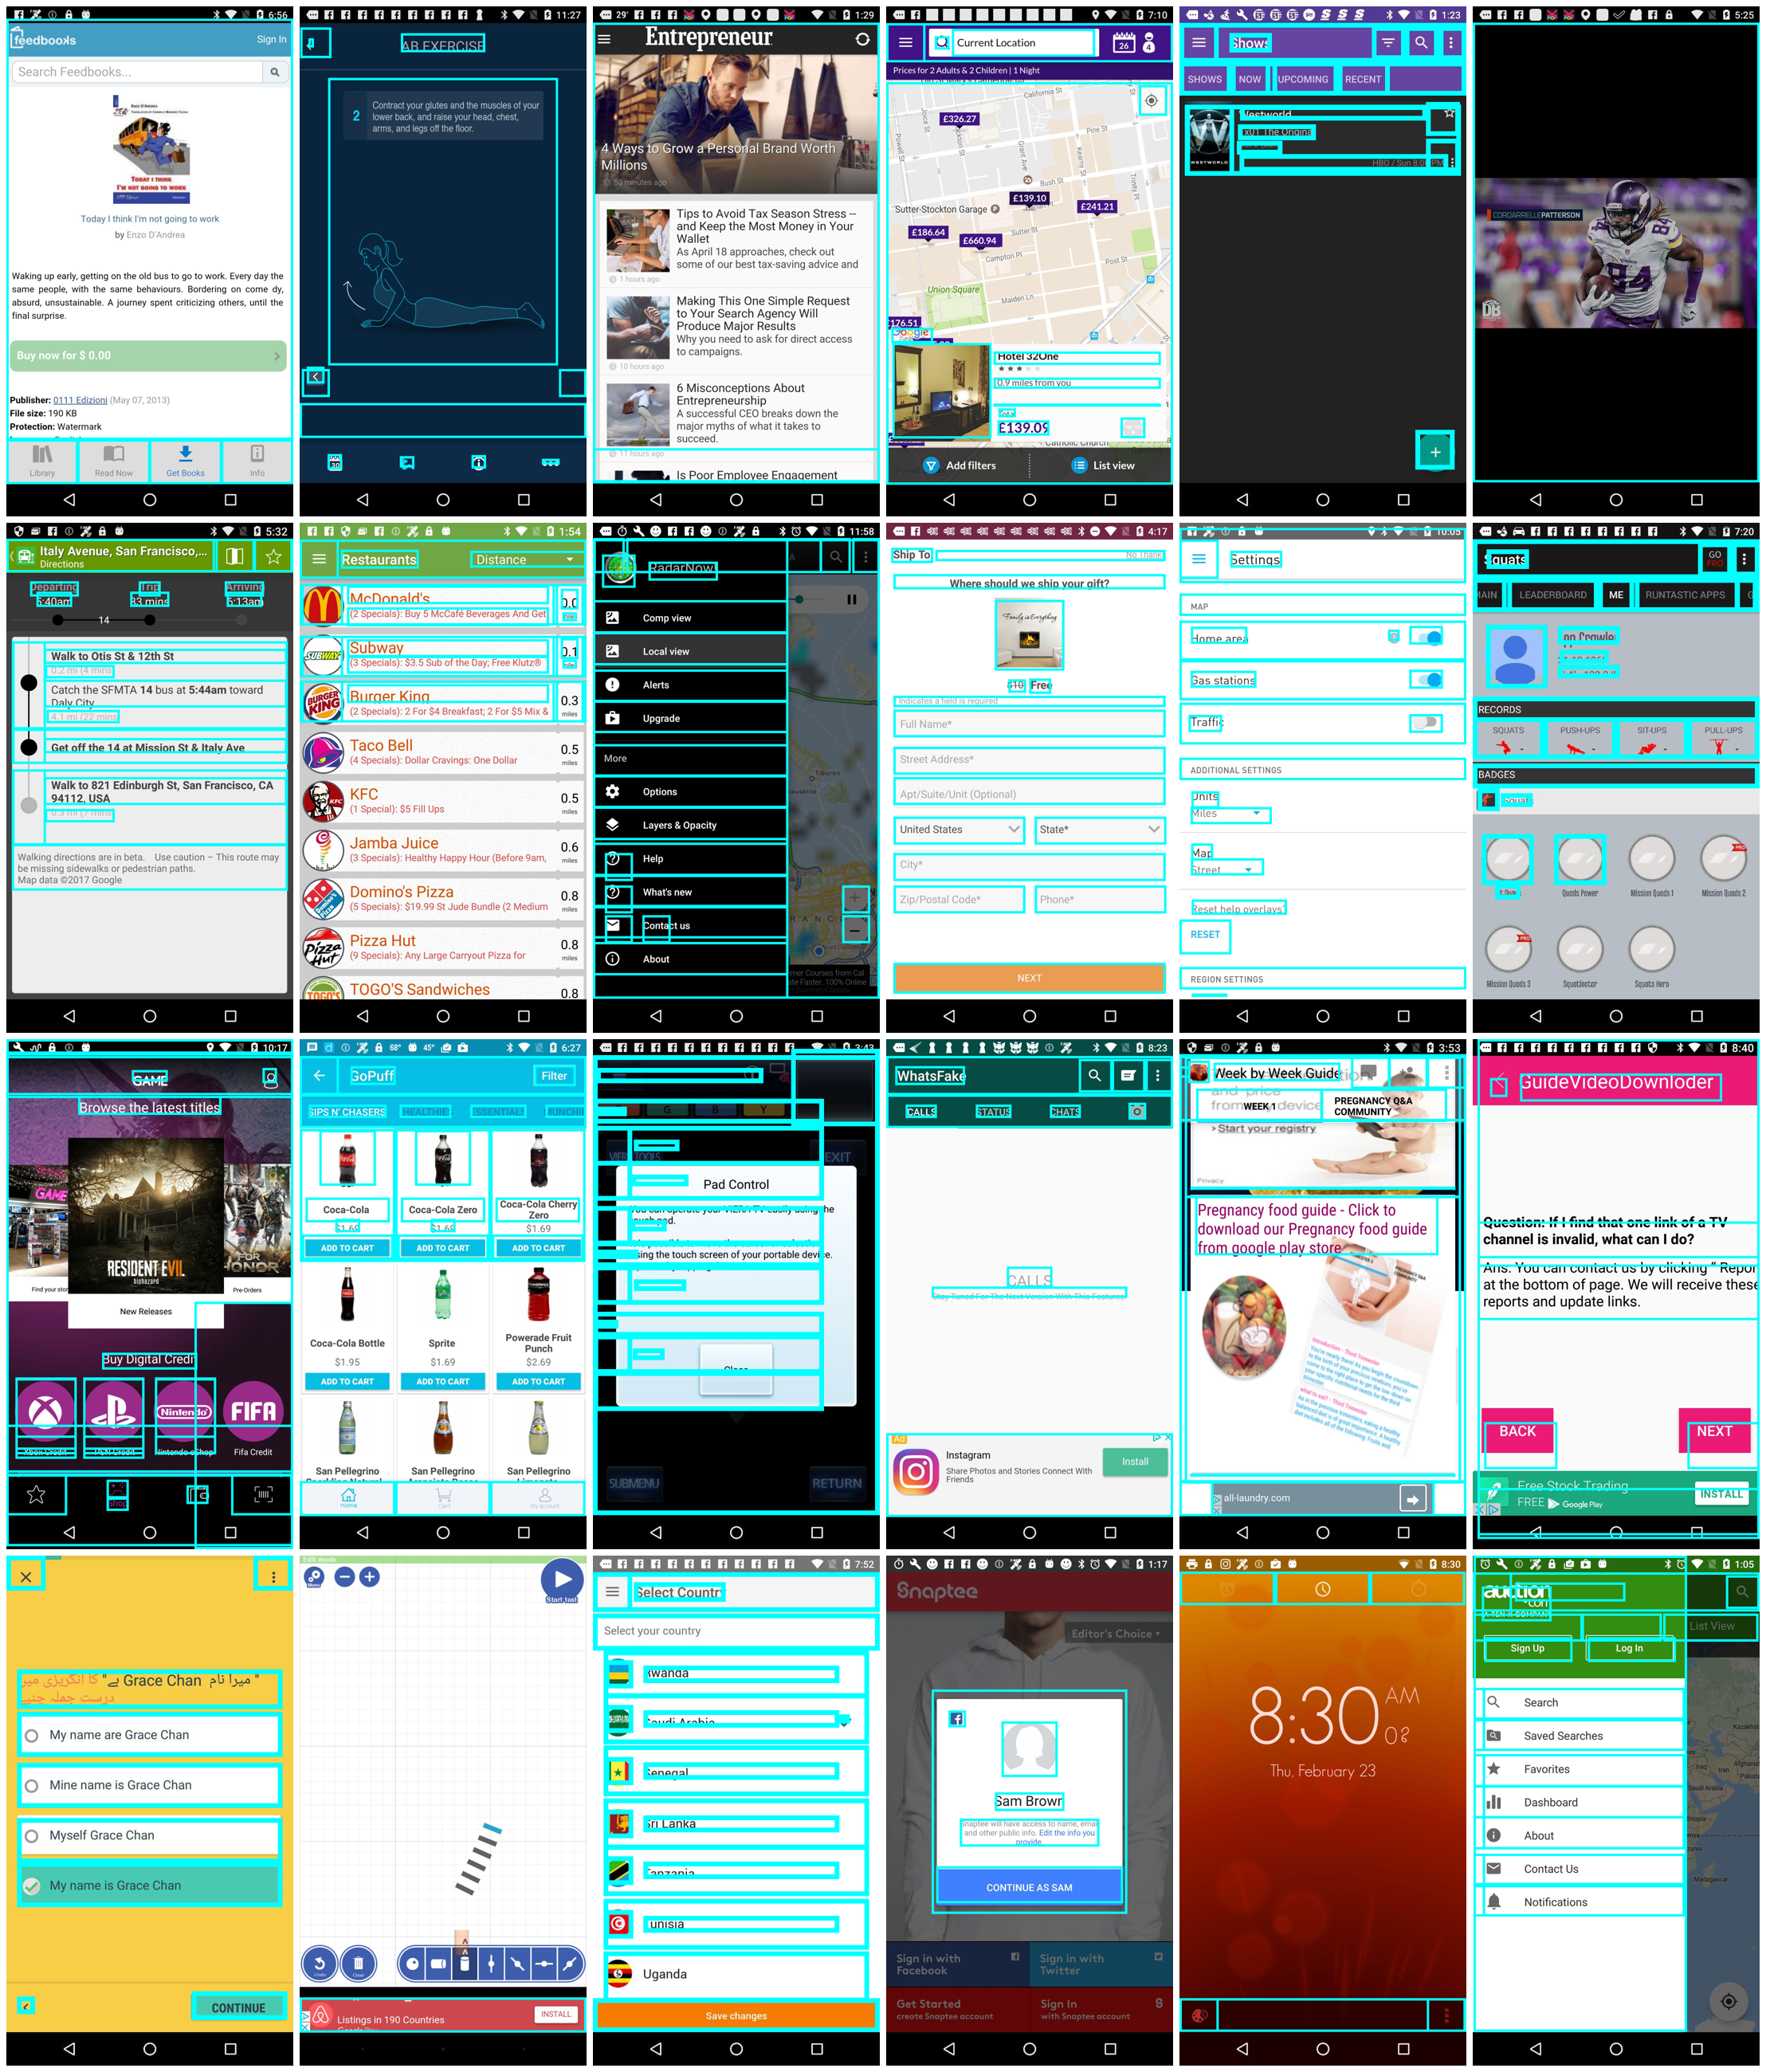

In [32]:
from IPython.display import display, Image as IPImage

display(IPImage(filename="/content/layoutdm_rico_tokens/debug_overlays/grid_overlays.png"))

In [21]:
DRIVE_ARTIFACTS_DIR = '/content/drive/MyDrive/data/layoutdm_artifacts'

In [22]:
train_path = os.path.join(OUT_DIR, "tokens_train.pt")
val_path = os.path.join(OUT_DIR, "tokens_val.pt")
test_path = os.path.join(OUT_DIR, "tokens_test.pt")


In [23]:
cp /content/layoutdm_rico_tokens/tokens_train.pt /content/drive/MyDrive/data/layoutdm_artifacts

In [24]:
cp /content/layoutdm_rico_tokens/tokens_val.pt /content/drive/MyDrive/data/layoutdm_artifacts


In [25]:
cp /content/layoutdm_rico_tokens/tokens_test.pt /content/drive/MyDrive/data/layoutdm_artifacts

In [26]:
cp /content/layoutdm_rico_tokens/vocab_meta.json /content/drive/MyDrive/data/layoutdm_artifacts

In [27]:
cp /content/layoutdm_rico_tokens/centroids_x.pt /content/drive/MyDrive/data/layoutdm_artifacts

In [28]:
cp /content/layoutdm_rico_tokens/centroids_y.pt /content/drive/MyDrive/data/layoutdm_artifacts

In [29]:
cp /content/layoutdm_rico_tokens/centroids_w.pt /content/drive/MyDrive/data/layoutdm_artifacts

In [30]:
cp /content/layoutdm_rico_tokens/centroids_h.pt /content/drive/MyDrive/data/layoutdm_artifacts

In [31]:
cp /content/layoutdm_rico_tokens/cat2id.json /content/drive/MyDrive/data/layoutdm_artifacts

In [35]:
tokens_train = torch.load(os.path.join(OUT_DIR, "tokens_train.pt")).cpu()

torch.Size([52954, 25, 5])